<a href="https://colab.research.google.com/github/CiceroFranklin/CiceroFranklin.github.io/blob/main/Islandisation_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Islandisation of Central America — working notebook

Pipeline: **geography → network routing → gravity regression → epidemic model**.

Geometry: Central American countries drift apart until every pair of coastlines is at least
`GAP_KM` apart, with Mexico and Colombia pinned. `GAP_KM` is the dial you sweep for trials.


## Section A — geography, network & routing

In [1]:
# --- setup & node table -------------------------------------------------
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

nodes = pd.DataFrame([
    # name,            iso3,   lat,     lon,   role,      type
    ("Guatemala City", "GTM", 14.63,  -90.51, "capital", "CA"),
    ("Puerto Barrios", "GTM", 15.73,  -88.60, "port",    "CA"),
    ("Belmopan",       "BLZ", 17.25,  -88.77, "capital", "CA"),
    ("Belize City",    "BLZ", 17.50,  -88.20, "port",    "CA"),
    ("San Salvador",   "SLV", 13.69,  -89.19, "capital", "CA"),
    ("Acajutla",       "SLV", 13.59,  -89.83, "port",    "CA"),
    ("Tegucigalpa",    "HND", 14.07,  -87.19, "capital", "CA"),
    ("Puerto Cortes",  "HND", 15.83,  -87.93, "port",    "CA"),
    ("Managua",        "NIC", 12.11,  -86.24, "capital", "CA"),
    ("Corinto",        "NIC", 12.48,  -87.17, "port",    "CA"),
    ("San Jose",       "CRI",  9.93,  -84.08, "capital", "CA"),
    ("Puerto Limon",   "CRI",  9.99,  -83.03, "port",    "CA"),
    ("Panama City",    "PAN",  8.98,  -79.52, "capital", "CA"),
    ("Colon",          "PAN",  9.36,  -79.90, "port",    "CA"),
    # --- anchors / external (do NOT move) ---
    ("Tapachula",      "MEX", 14.90,  -92.26, "border",  "anchor"),
    ("Salina Cruz",    "MEX", 16.16,  -95.20, "port",    "anchor"),
    ("Veracruz",       "MEX", 19.19,  -96.14, "port",    "anchor"),
    ("Cartagena",      "COL", 10.40,  -75.51, "port",    "anchor"),
    ("Bogota",         "COL",  4.71,  -74.07, "capital", "anchor"),
    ("Puerto Cabello", "VEN", 10.47,  -68.01, "port",    "external"),
    ("Guayaquil",      "ECU", -2.19,  -79.88, "port",    "external"),
    ("Houston",        "USA", 29.76,  -95.36, "port",    "destination"),
    ("Miami",          "USA", 25.76,  -80.19, "port",    "destination"),
], columns=["name","iso3","lat","lon","role","type"])

# coast each PORT faces; inland nodes -> NaN
coast = {
 "Puerto Barrios":"CAR","Belize City":"CAR","Puerto Cortes":"CAR","Puerto Limon":"CAR",
 "Colon":"CAR","Veracruz":"CAR","Cartagena":"CAR","Puerto Cabello":"CAR",
 "Houston":"CAR","Miami":"CAR",
 "Acajutla":"PAC","Corinto":"PAC","Panama City":"PAC","Salina Cruz":"PAC",
 "Guayaquil":"PAC","Tapachula":"PAC",
}
nodes["coast"]   = nodes.name.map(coast)
nodes["is_port"] = nodes.coast.notna()

areas = {"GTM":108889,"BLZ":22966,"SLV":21041,"HND":112492,
         "NIC":130373,"CRI":51100,"PAN":75417}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

print(nodes[["name","iso3","coast","is_port"]].to_string(index=False))


          name iso3 coast  is_port
Guatemala City  GTM   NaN    False
Puerto Barrios  GTM   CAR     True
      Belmopan  BLZ   NaN    False
   Belize City  BLZ   CAR     True
  San Salvador  SLV   NaN    False
      Acajutla  SLV   PAC     True
   Tegucigalpa  HND   NaN    False
 Puerto Cortes  HND   CAR     True
       Managua  NIC   NaN    False
       Corinto  NIC   PAC     True
      San Jose  CRI   NaN    False
  Puerto Limon  CRI   CAR     True
   Panama City  PAN   PAC     True
         Colon  PAN   CAR     True
     Tapachula  MEX   PAC     True
   Salina Cruz  MEX   PAC     True
      Veracruz  MEX   CAR     True
     Cartagena  COL   CAR     True
        Bogota  COL   NaN    False
Puerto Cabello  VEN   CAR     True
     Guayaquil  ECU   PAC     True
       Houston  USA   CAR     True
         Miami  USA   CAR     True


In [2]:
# --- load country polygons (needed by the geometry step) -----------------
!pip install -q geopandas
import geopandas as gpd
from shapely.affinity import translate
from shapely.ops import unary_union, nearest_points

# primary source; if it fails, try the GitHub mirror below
try:
    URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(URL)
except Exception:
    URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
           "master/geojson/ne_110m_admin_0_countries.geojson")
    world = gpd.read_file(URL)

world = world.rename(columns={"ADM0_A3":"iso3"})
CA     = ["GTM","BLZ","SLV","HND","NIC","CRI","PAN"]   # movable
ANCHOR = ["MEX","COL"]                                  # pinned
ALLC   = CA + ANCHOR
poly = {c: unary_union(world.loc[world.iso3==c,"geometry"].values) for c in ALLC}
print("loaded polygons:", {c: round(poly[c].area,1) for c in ALLC})


loaded polygons: {'GTM': 9.2, 'BLZ': 1.9, 'SLV': 1.7, 'HND': 9.6, 'NIC': 10.8, 'CRI': 4.4, 'PAN': 6.2, 'MEX': 175.2, 'COL': 93.9}


### Islandisation geometry — drift-until-separated

**The algorithm (this is the assumption you state in the writeup):**

1. *Seed.* Nudge the Central American countries apart with a mild radial expansion from the
   centre of the isthmus, so they start moving in sensible directions.
2. *Relax.* Repeat: for every pair of countries whose coastlines are closer than `GAP_KM`,
   push them **directly apart along the line joining their nearest points** — i.e. each island
   moves away from whatever land it is closest to. Mexico and Colombia are **pinned**, so
   Guatemala and Panama get pushed away from them rather than into them.
3. Stop when every pair of coastlines is at least `GAP_KM` apart.

This is a physical repulsion process, not an arbitrary displacement: the resulting map is
whatever configuration satisfies "every island has at least `GAP_KM` of open sea around it,
having moved as little as possible from where it started."

`GAP_KM` — the minimum sea channel width — is your **trials dial**. It is more interpretable
than an abstract expansion factor because it is a physical distance you can talk about.

In [3]:
# --- ISLANDISATION: drift until separated --------------------------------
DEG = 111.0          # km per degree (fine at these latitudes)

def islandise(GAP_KM=60, SEED_ALPHA=1.25, N_ITER=600, STEP=0.5, verbose=True):
    """Push CA countries apart until every coastline pair is >= GAP_KM apart.
       Mexico and Colombia are fixed. Returns per-country displacement (degrees)."""
    GAP = GAP_KM/DEG
    ctr = {c:(poly[c].centroid.x, poly[c].centroid.y) for c in ALLC}
    cx = np.mean([ctr[c][0] for c in CA]); cy = np.mean([ctr[c][1] for c in CA])

    # 1. seed with a mild radial expansion so nothing starts perfectly stuck
    disp = {c: np.zeros(2) for c in ALLC}
    for c in CA:
        ox, oy = ctr[c]
        disp[c] = np.array([(cx+SEED_ALPHA*(ox-cx))-ox, (cy+SEED_ALPHA*(oy-cy))-oy])

    shp = lambda c: translate(poly[c], xoff=disp[c][0], yoff=disp[c][1])

    # 2. relax: each country drifts away from whatever land it is nearest to
    for it in range(N_ITER):
        shapes = {c: shp(c) for c in ALLC}
        moved = False
        for i, a in enumerate(ALLC):
            for b in ALLC[i+1:]:
                deficit = GAP - shapes[a].distance(shapes[b])
                if deficit <= 1e-6:          # tolerance: treat as satisfied
                    continue
                moved = True
                pa, pb = nearest_points(shapes[a], shapes[b])   # closest coastline points
                v = np.array([pb.x-pa.x, pb.y-pa.y]); nv = np.linalg.norm(v)
                if nv < 1e-9:                                    # overlapping -> use centroids
                    ca, cb = shapes[a].centroid, shapes[b].centroid
                    v = np.array([cb.x-ca.x, cb.y-ca.y]); nv = np.linalg.norm(v)
                    if nv < 1e-9: v, nv = np.array([1.0, 0.0]), 1.0
                v = v/nv
                mov = [x for x in (a, b) if x in CA]             # anchors absorb no push
                if not mov: continue
                push = v*deficit*STEP/len(mov)
                if a in CA: disp[a] -= push
                if b in CA: disp[b] += push
        if not moved:
            if verbose: print(f"converged after {it} iterations")
            break
    else:
        if verbose: print(f"stopped at {N_ITER} iterations (target may be infeasible)")
    return disp

# ============ THE DIAL ============
GAP_KM = 60      # minimum sea channel between any two coastlines
# ==================================
disp = islandise(GAP_KM=GAP_KM)

shift = pd.DataFrame({c: disp[c] for c in ALLC}, index=["dlon","dlat"]).T
shift = shift.reindex(nodes.iso3.unique()).fillna(0.0)      # anchors/externals -> 0
shift["km_moved"] = np.hypot(shift.dlon, shift.dlat)*DEG
print(shift.loc[CA].round(2).to_string())

# apply the same displacement to cities and to polygons
nodes_post = nodes.copy()
nodes_post["lon"] = nodes.lon + nodes.iso3.map(shift.dlon).astype(float)
nodes_post["lat"] = nodes.lat + nodes.iso3.map(shift.dlat).astype(float)

world_post = world.copy()
world_post["geometry"] = [
    translate(gm, xoff=float(shift.dlon.get(c,0.0)), yoff=float(shift.dlat.get(c,0.0)))
    for gm, c in zip(world_post.geometry, world_post.iso3)]

# --- verification: every gap should be >= GAP_KM, anchors included ---
fin = {c: translate(poly[c], xoff=disp[c][0], yoff=disp[c][1]) for c in ALLC}
gaps = sorted([(a,b,fin[a].distance(fin[b])*DEG)
               for i,a in enumerate(ALLC) for b in ALLC[i+1:]], key=lambda t:t[2])
print(f"\n6 smallest coastline gaps (target {GAP_KM} km):")
for a,b,d in gaps[:6]:
    print(f"  {a}-{b}: {d:.0f} km" + ("   <-- ANCHOR" if a in ANCHOR or b in ANCHOR else ""))


converged after 191 iterations
     dlon  dlat  km_moved
GTM  1.08 -1.72    225.08
BLZ  2.13  1.05    263.31
SLV  1.18 -2.44    301.15
HND  1.82  0.80    220.49
NIC  1.94 -0.33    218.57
CRI -1.47 -1.25    213.55
PAN -0.77  0.62    109.98

6 smallest coastline gaps (target 60 km):
  BLZ-MEX: 60 km   <-- ANCHOR
  GTM-MEX: 60 km   <-- ANCHOR
  NIC-PAN: 60 km
  PAN-COL: 60 km   <-- ANCHOR
  GTM-HND: 60 km
  HND-NIC: 60 km


### The new map

Check this before trusting anything downstream: no country should overlap another, and
Guatemala/Panama should be clear of Mexico/Colombia.

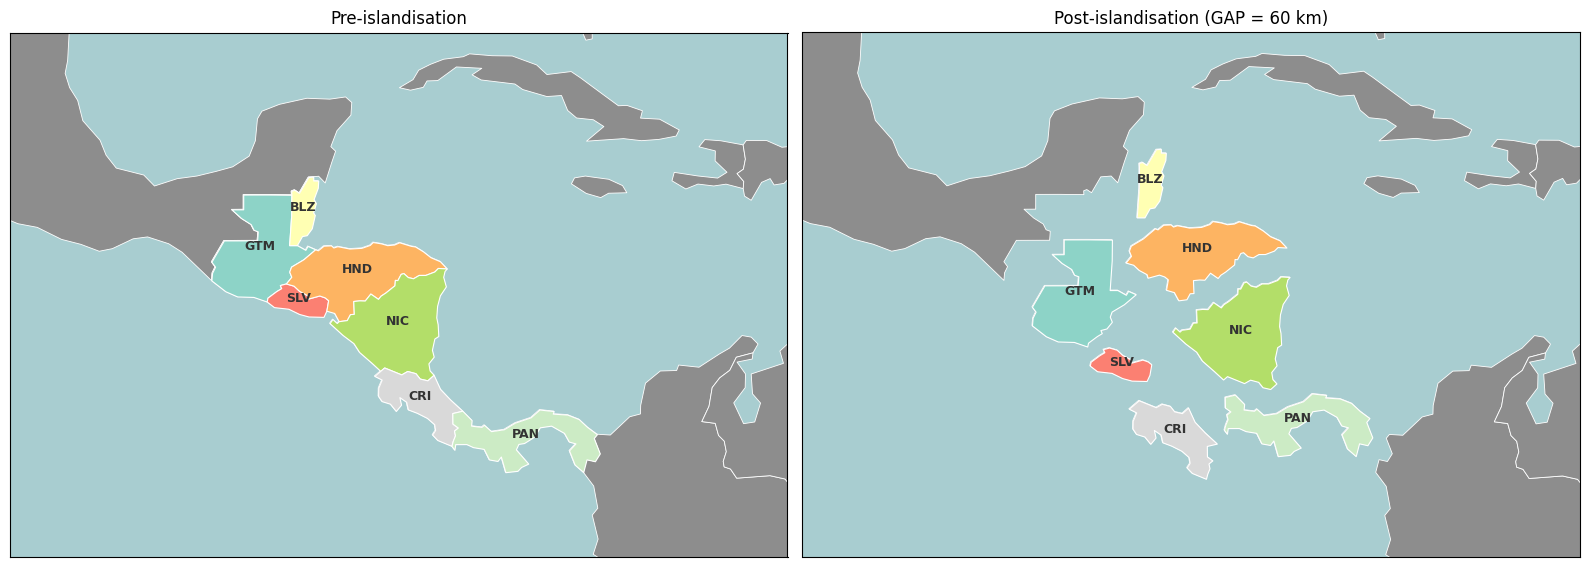

In [4]:
# --- before/after map ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, gdf, title in [(axes[0], world, "Pre-islandisation"),
                       (axes[1], world_post, f"Post-islandisation (GAP = {GAP_KM} km)")]:
    ax.set_facecolor("#a8cdd0")
    gdf.plot(ax=ax, color="#8d8d8d", edgecolor="white", lw=0.6)
    for k, c in enumerate(CA):
        gdf[gdf.iso3 == c].plot(ax=ax, color=plt.cm.Set3(k/7), edgecolor="white", lw=0.8)
        cen = gdf.loc[gdf.iso3 == c, "geometry"].iloc[0].centroid
        ax.annotate(c, (cen.x, cen.y), fontsize=9, ha="center", weight="bold", color="0.2")
    ax.set_xlim(-100, -70); ax.set_ylim(4, 24)
    ax.set_title(title, fontsize=12); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); fig.savefig("fig0_geometry.png", dpi=300, bbox_inches="tight"); plt.show()


### Build the two networks

`build_graph` connects every pair of cities with a **land** edge (same country, or bordering
countries in the *pre* world only), a **sea** edge (both ports, same ocean), plus the Panama
Canal as the single Pacific↔Caribbean link. Cost = distance × mode-rate, with a fixed handling
charge per sea leg (this is what makes short hops expensive and concentrates traffic on hubs).

In [5]:
# --- network construction ------------------------------------------------
land_adj = [("MEX","GTM"),("MEX","BLZ"),("GTM","BLZ"),("GTM","SLV"),("GTM","HND"),
            ("SLV","HND"),("HND","NIC"),("NIC","CRI"),("CRI","PAN"),("PAN","COL")]
land_adj = {frozenset(p) for p in land_adj}

# cost parameters — tune land_per_km vs sea_per_km so PRE routes look sensible
P = dict(land_per_km=1.00, sea_per_km=0.35, sea_handling=150.0,
         canal_toll=120.0, darien_mult=4.0, max_sea_km=4000.0)

def build_graph(coords, world, P=P):
    nm  = coords["name"].tolist();  iso = coords["iso3"].tolist()
    la  = coords["lat"].tolist();   lo  = coords["lon"].tolist()
    cst = coords["coast"].tolist(); isp = coords["is_port"].tolist()
    G = nx.Graph()
    for k in range(len(nm)):
        G.add_node(nm[k], iso3=iso[k], lat=la[k], lon=lo[k], is_port=bool(isp[k]))
    for i in range(len(nm)):
        for j in range(i+1, len(nm)):
            d = haversine(la[i], lo[i], la[j], lo[j])
            pair = frozenset((iso[i], iso[j]))
            same = iso[i] == iso[j]
            nbr  = pair in land_adj
            # LAND: within a country always; across borders only pre-islandisation
            if (same or (world=="pre" and nbr)) and d <= 1200:
                cost = d*P["land_per_km"]
                if pair == frozenset(("PAN","COL")):   # Darien Gap: broken even today
                    cost *= P["darien_mult"]
                G.add_edge(nm[i], nm[j], cost=cost, mode="land", km=d)
            # SEA: both ports, same ocean
            if isp[i] and isp[j] and cst[i]==cst[j] and d <= P["max_sea_km"]:
                cost = d*P["sea_per_km"] + P["sea_handling"]
                if G.has_edge(nm[i], nm[j]):
                    if cost < G[nm[i]][nm[j]]["cost"]:
                        G[nm[i]][nm[j]].update(cost=cost, mode="sea", km=d)
                else:
                    G.add_edge(nm[i], nm[j], cost=cost, mode="sea", km=d)
    G.add_edge("Panama City","Colon", cost=P["canal_toll"], mode="canal", km=80)
    return G

G_pre  = build_graph(nodes,      "pre")
G_post = build_graph(nodes_post, "post")
print(G_pre.number_of_edges(), "pre edges |", G_post.number_of_edges(),
      "post edges   (post MUST be fewer -> land bridge deleted)")
print("Cartagena neighbours (pre):", list(G_pre.neighbors("Cartagena")))


108 pre edges | 70 post edges   (post MUST be fewer -> land bridge deleted)
Cartagena neighbours (pre): ['Puerto Barrios', 'Belize City', 'Puerto Cortes', 'Puerto Limon', 'Panama City', 'Colon', 'Veracruz', 'Bogota', 'Puerto Cabello', 'Houston', 'Miami']


### Route the commodity flows

Three tiers of flow: long-haul South→North (already maritime, should barely move),
Central-American exports northward (land-dependent), and intra-CA trade (most exposed).
The **heterogeneity across tiers is the headline finding**, not the single average.

In [6]:
# --- flows & routing -----------------------------------------------------
FLOWS = [
    # long-haul South -> North (baseline: already maritime)
    ("Cartagena",     "Houston", 12_000, "coffee (COL)"),
    ("Puerto Cabello","Houston", 25_000, "crude oil (VEN)"),
    ("Guayaquil",     "Houston", 15_000, "bananas (ECU)"),
    # Central American exports northward (land-dependent)
    ("Guatemala City","Veracruz",  9_000, "apparel (GTM)"),
    ("San Salvador",  "Tapachula", 6_000, "apparel (SLV)"),
    ("Tegucigalpa",   "Houston",   7_000, "coffee (HND)"),
    ("Managua",       "Veracruz",  4_000, "beef (NIC)"),
    ("San Jose",      "Miami",     8_000, "medical devices (CRI)"),
    # intra-Central-American trade (most exposed)
    ("Guatemala City","Panama City",   3_000, "intra-CA manufactures"),
    ("San Salvador",  "San Jose",      2_500, "intra-CA food"),
    ("Tegucigalpa",   "Managua",       2_000, "intra-CA goods"),
    ("Belmopan",      "Guatemala City",1_200, "intra-CA goods"),
]
TIER = (["long-haul"]*3 + ["CA export"]*5 + ["intra-CA"]*4)

def route_all(G, flows=FLOWS):
    rows, node_flow = [], {}
    for o,d,tons,good in flows:
        try:
            path = nx.dijkstra_path(G, o, d, weight="cost")
            cost = nx.dijkstra_path_length(G, o, d, weight="cost")
        except nx.NetworkXNoPath:
            rows.append(dict(o=o,d=d,good=good,tons=tons,cost=np.nan,km=np.nan,path="NO PATH"))
            continue
        km = sum(G[u][v]["km"] for u,v in zip(path,path[1:]))
        for n in path[1:-1]:
            node_flow[n] = node_flow.get(n,0)+tons
        rows.append(dict(o=o,d=d,good=good,tons=tons,cost=round(cost),
                         km=round(km),path=" > ".join(path)))
    return pd.DataFrame(rows), node_flow

pre,  nf_pre  = route_all(G_pre)
post, nf_post = route_all(G_post)

cmp = pre[["o","d","good","cost","km"]].merge(
      post[["o","d","cost","km"]], on=["o","d"], suffixes=("_pre","_post"))
cmp["tier"] = TIER
cmp["cost_change_%"] = (100*(cmp.cost_post/cmp.cost_pre - 1)).round(1)
print(cmp[["tier","good","cost_pre","cost_post","cost_change_%"]].to_string(index=False))

print("\ncost change by tier (%):")
print(cmp.groupby("tier")["cost_change_%"].mean().round(1).to_string())

ok = pre.cost.notna() & post.cost.notna()
w_pre  = (pre.cost[ok]*pre.tons[ok]).sum()/pre.tons[ok].sum()
w_post = (post.cost[ok]*post.tons[ok]).sum()/post.tons[ok].sum()
print(f"\nWeighted mean cost: {w_pre:,.0f} -> {w_post:,.0f} ({100*(w_post/w_pre-1):+.1f}%)")

nopath = post[post.path=="NO PATH"]
if len(nopath):
    print("\nStranded post-islandisation (finding, not bug):")
    print(nopath[["o","d","good"]].to_string(index=False))


     tier                  good  cost_pre  cost_post  cost_change_%
long-haul          coffee (COL)      1192       1192            0.0
long-haul       crude oil (VEN)      1394       1394            0.0
long-haul         bananas (ECU)      1828       1816           -0.7
CA export         apparel (GTM)       699        769           10.0
CA export         apparel (SLV)       325        421           29.5
CA export          coffee (HND)       965        969            0.4
CA export            beef (NIC)       934       1018            9.0
CA export medical devices (CRI)       888        947            6.6
 intra-CA intra-CA manufactures       719        814           13.2
 intra-CA         intra-CA food       770       1086           41.0
 intra-CA        intra-CA goods       241       1284          432.8
 intra-CA        intra-CA goods       346        641           85.3

cost change by tier (%):
tier
CA export     11.1
intra-CA     143.1
long-haul     -0.2

Weighted mean cost: 1,134 -

### Visual 1 — routed flows, before vs after

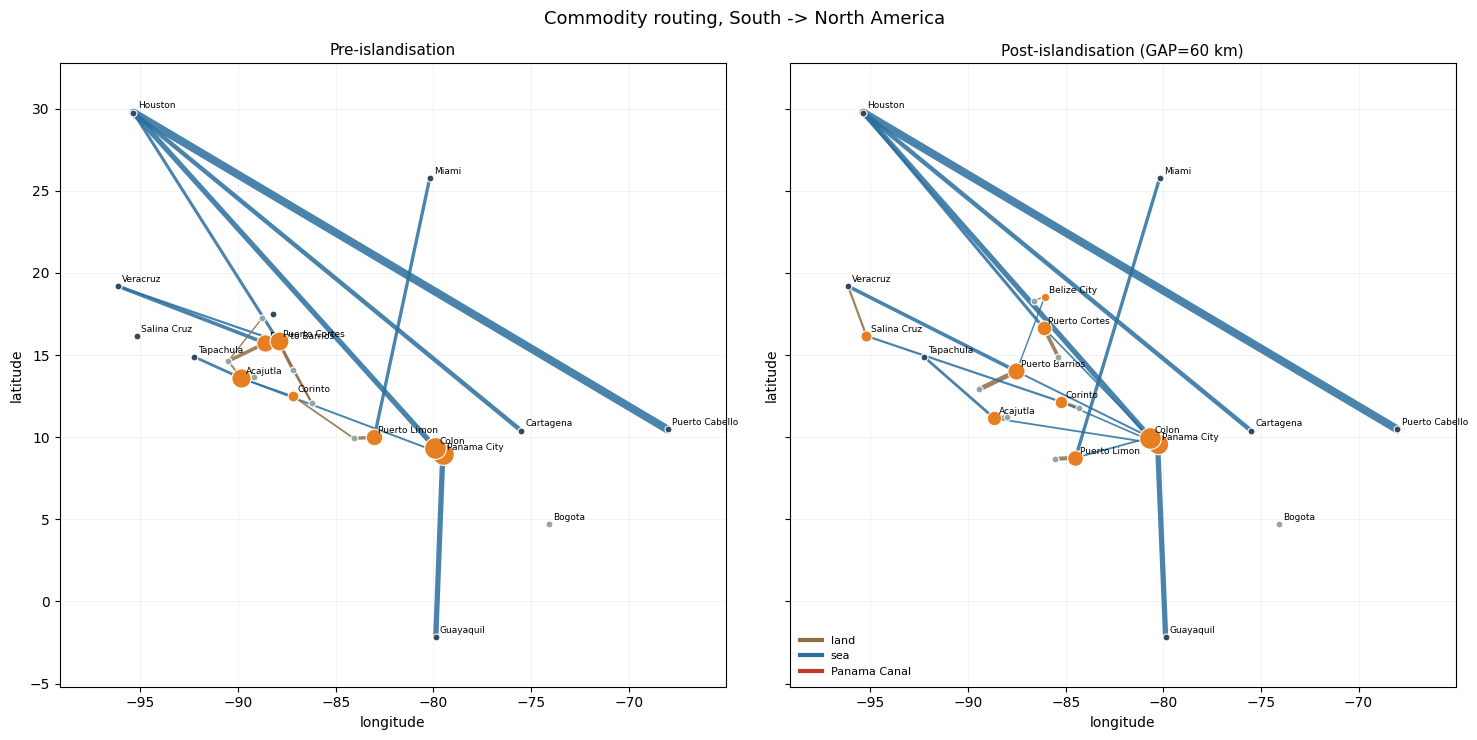

In [7]:
# --- drawing helper ------------------------------------------------------
MODE_COLOR = {"land":"#8c6d46","sea":"#2a6f9e","canal":"#c0392b"}

def draw_world(G, coords, routes, ax, title, show_all_edges=False):
    pos = {r.name:(r.lon, r.lat) for r in coords.itertuples()}
    if show_all_edges:
        for u,v in G.edges():
            ax.plot([pos[u][0],pos[v][0]],[pos[u][1],pos[v][1]],color="0.85",lw=0.6,zorder=1)
    used={}
    for r in routes.itertuples():
        if r.path=="NO PATH": continue
        seq=r.path.split(" > ")
        for u,v in zip(seq,seq[1:]):
            key=(u,v) if u<v else (v,u); used[key]=used.get(key,0)+r.tons
    maxt=max(used.values()) if used else 1
    for (u,v),tons in used.items():
        ax.plot([pos[u][0],pos[v][0]],[pos[u][1],pos[v][1]],
                color=MODE_COLOR.get(G[u][v]["mode"],"0.3"),
                lw=0.8+5.0*tons/maxt,alpha=0.85,zorder=2,solid_capstyle="round")
    thru={}
    for r in routes.itertuples():
        if r.path=="NO PATH": continue
        for n in r.path.split(" > ")[1:-1]: thru[n]=thru.get(n,0)+r.tons
    mx=max(thru.values()) if thru else 1
    for r in coords.itertuples():
        x,y=pos[r.name]; t=thru.get(r.name,0)
        ax.scatter(x,y,s=25+220*t/mx,zorder=3,
                   c="#e67e22" if t else ("#34495e" if r.is_port else "#95a5a6"),
                   edgecolors="white",linewidths=0.8)
        if t or r.type!="CA":
            ax.annotate(r.name,(x,y),fontsize=6.5,xytext=(3,3),textcoords="offset points")
    ax.set_title(title,fontsize=11); ax.grid(alpha=0.25,lw=0.4)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

fig,axes=plt.subplots(1,2,figsize=(15,7.5),sharex=True,sharey=True)
draw_world(G_pre, nodes,      pre,  axes[0], f"Pre-islandisation")
draw_world(G_post,nodes_post, post, axes[1], f"Post-islandisation (GAP={GAP_KM} km)")
allx=list(nodes.lon)+list(nodes_post.lon); ally=list(nodes.lat)+list(nodes_post.lat)
axes[0].set_xlim(min(allx)-3,max(allx)+3); axes[0].set_ylim(min(ally)-3,max(ally)+3)
leg=[Line2D([0],[0],color=MODE_COLOR["land"],lw=3,label="land"),
     Line2D([0],[0],color=MODE_COLOR["sea"],lw=3,label="sea"),
     Line2D([0],[0],color=MODE_COLOR["canal"],lw=3,label="Panama Canal")]
axes[1].legend(handles=leg,fontsize=8,loc="lower left",frameon=False)
fig.suptitle("Commodity routing, South -> North America",fontsize=13)
fig.tight_layout(); plt.show()


### Visual 1b — the same, on real country shapes

Downloads Natural Earth country polygons and applies the **same radial shift** to each
Central American country's shape that we applied to its cities. Rigid translation keeps each
country's full land area, so islands look like the countries slid apart (note this in the writeup —
real fragmentation would drown lowlands).

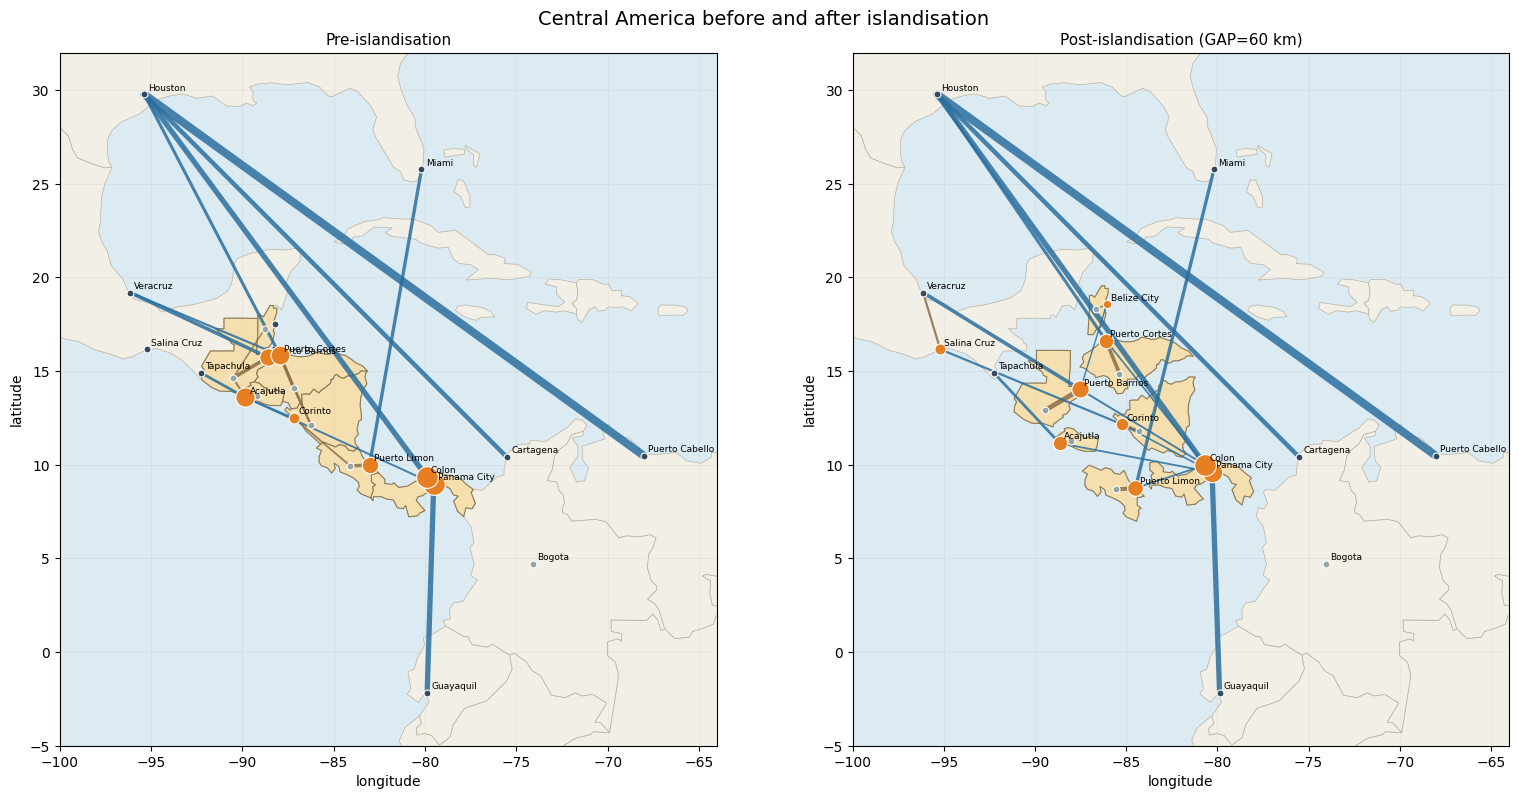

In [8]:
# --- polygon map (optional but makes the best figure) --------------------
try:
    import geopandas as gpd
    from shapely.affinity import translate
    from shapely.ops import unary_union

    URL="https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(URL).rename(columns={"ADM0_A3":"iso3"})

    world_post = world.copy()
    world_post["geometry"] = [
        translate(gm, xoff=float(shift.dlon.get(c,0.0)), yoff=float(shift.dlat.get(c,0.0)))
        for gm,c in zip(world_post.geometry, world_post.iso3)]

    def draw_map(gdf,G,coords,routes,ax,title):
        ax.set_facecolor("#dceaf2")
        gdf.plot(ax=ax,color="#f2efe6",edgecolor="#b9b2a3",lw=0.5)
        gdf[gdf.iso3.isin(CA)].plot(ax=ax,color="#f6dfae",edgecolor="#8a7a55",lw=0.8)
        draw_world(G,coords,routes,ax,title,show_all_edges=False)

    fig,axes=plt.subplots(1,2,figsize=(16,8))
    draw_map(world,      G_pre,  nodes,      pre,  axes[0], "Pre-islandisation")
    draw_map(world_post, G_post, nodes_post, post, axes[1], f"Post-islandisation (GAP={GAP_KM} km)")
    for ax in axes: ax.set_xlim(-100,-64); ax.set_ylim(-5,32)
    fig.suptitle("Central America before and after islandisation",fontsize=14)
    fig.tight_layout(); fig.savefig("fig1_map.png",dpi=300,bbox_inches="tight"); plt.show()
except Exception as e:
    print("Map skipped (geopandas/download issue):", e)
    print("The routing results above do not depend on this cell.")


### Trials — sweep `GAP_KM` (this is your experiment)

Re-run the geometry and routing at a range of channel widths and record the weighted trade
cost. The jump between 0 and the first positive value is the land bridge being deleted.

 GAP_KM  weighted_cost  stranded  cost_vs_today_pct
      0           1134         0                0.0
     25           1185         0                4.5
     50           1189         0                4.9
     75           1197         0                5.6
    100           1194         0                5.3
    150           1200         0                5.8
    200           1215         0                7.1


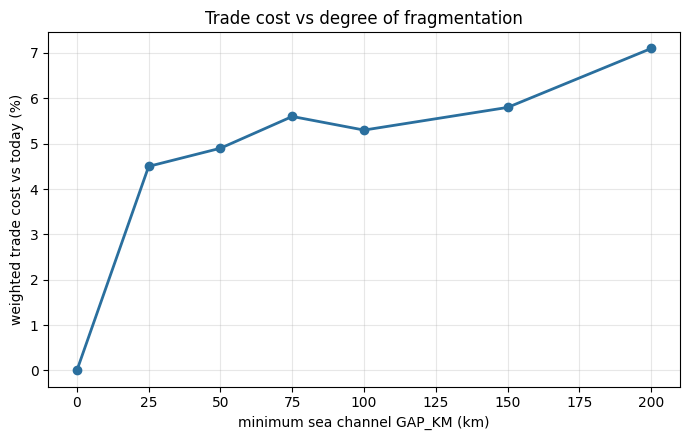

In [9]:
# --- trials: sweep the channel width GAP_KM ------------------------------
def post_nodes_for(gap_km):
    d = islandise(GAP_KM=gap_km, verbose=False)
    s = pd.DataFrame({c:d[c] for c in ALLC}, index=["dlon","dlat"]).T
    s = s.reindex(nodes.iso3.unique()).fillna(0.0)
    out = nodes.copy()
    out["lon"] = nodes.lon + nodes.iso3.map(s.dlon).astype(float)
    out["lat"] = nodes.lat + nodes.iso3.map(s.dlat).astype(float)
    return out

rows=[]
for gap in [0, 25, 50, 75, 100, 150, 200]:
    if gap == 0:
        Gp, lbl = G_pre, "pre"
    else:
        Gp, lbl = build_graph(post_nodes_for(gap), "post"), "post"
    r,_ = route_all(Gp)
    ok = r.cost.notna()
    wc = (r.cost[ok]*r.tons[ok]).sum()/r.tons[ok].sum()
    tiers = pd.Series(TIER, index=r.index)
    rows.append(dict(GAP_KM=gap, weighted_cost=round(wc),
                     stranded=int((r.path=="NO PATH").sum())))
sweep = pd.DataFrame(rows)
sweep["cost_vs_today_pct"] = (100*(sweep.weighted_cost/sweep.weighted_cost.iloc[0]-1)).round(1)
print(sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(sweep.GAP_KM, sweep.cost_vs_today_pct, "o-", color="#2a6f9e", lw=2)
ax.set_xlabel("minimum sea channel GAP_KM (km)")
ax.set_ylabel("weighted trade cost vs today (%)")
ax.set_title("Trade cost vs degree of fragmentation"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Section B — gravity model (needs the CEPII CSV)

Download the CEPII Gravity database (CSV) to your Google Drive first, then run these.
We estimate the distance elasticity of trade on the **global** sample (you need wide
variation in distance to identify the slope), then apply it to the **new** Central American
distances from Section A to predict the trade change.

In [10]:
# --- mount Drive & point at the file -------------------------------------
from google.colab import drive
drive.mount("/content/gdrive")

PATH = "/content/gdrive/MyDrive/Colab Notebooks/Gravity_V202211.csv"   # <-- EDIT to your path
peek = pd.read_csv(PATH, nrows=5)
print(len(peek.columns), "columns")
print(list(peek.columns))


Mounted at /content/gdrive
87 columns
['year', 'country_id_o', 'country_id_d', 'iso3_o', 'iso3_d', 'iso3num_o', 'iso3num_d', 'country_exists_o', 'country_exists_d', 'gmt_offset_2020_o', 'gmt_offset_2020_d', 'distw_harmonic', 'distw_arithmetic', 'distw_harmonic_jh', 'distw_arithmetic_jh', 'dist', 'main_city_source_o', 'main_city_source_d', 'distcap', 'contig', 'diplo_disagreement', 'scaled_sci_2021', 'comlang_off', 'comlang_ethno', 'comcol', 'col45', 'legal_old_o', 'legal_old_d', 'legal_new_o', 'legal_new_d', 'comleg_pretrans', 'comleg_posttrans', 'transition_legalchange', 'comrelig', 'heg_o', 'heg_d', 'col_dep_ever', 'col_dep', 'col_dep_end_year', 'col_dep_end_conflict', 'empire', 'sibling_ever', 'sibling', 'sever_year', 'sib_conflict', 'pop_o', 'pop_d', 'gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d', 'pop_source_o', 'pop_source_d', 'gdp_source_o', 'gdp_source_d', 'gdp_ppp_o', 'gdp_ppp_d', 'gdpcap_ppp_o', 'gdpcap_ppp_d', 'pop_pwt_o', 'pop_pwt_d', 'gdp_ppp_pwt_o', 'gdp_ppp_pwt_d', 'gatt_o', '

In [11]:
# --- load one year, clean, build logs ------------------------------------
COLS = ["year","iso3_o","iso3_d","tradeflow_baci","gdp_o","gdp_d",
        "dist","distw_harmonic","contig","comlang_off","comcol",
        "col_dep_ever","fta_wto"]
COLS = [c for c in COLS if c in peek.columns]   # keep only what exists
YEAR = 2019

chunks=[]
for ch in pd.read_csv(PATH, usecols=COLS, chunksize=500_000, low_memory=False):
    chunks.append(ch[ch.year==YEAR])
g = pd.concat(chunks, ignore_index=True)

LANDLOCKED={"AFG","BOL","PRY","MLI","NER","TCD","ETH","UGA","RWA","BDI","ZMB",
 "ZWE","BWA","MWI","AUT","CHE","CZE","HUN","SVK","SRB","MKD","MDA","BLR","ARM",
 "AZE","KAZ","KGZ","TJK","TKM","UZB","MNG","NPL","BTN","LAO","LUX","LIE","SSD"}
g["landlocked_o"]=g.iso3_o.isin(LANDLOCKED).astype(int)
g["landlocked_d"]=g.iso3_d.isin(LANDLOCKED).astype(int)

g = g.rename(columns={"tradeflow_baci":"trade"})
g = g[g.iso3_o != g.iso3_d]
n0=len(g)
g = g.dropna(subset=["trade","gdp_o","gdp_d","dist"])
g = g[(g.trade>0)&(g.gdp_o>0)&(g.gdp_d>0)]
print(f"{n0:,} pairs -> {len(g):,} after dropping zero/missing trade "
      f"({100*(1-len(g)/n0):.1f}% lost to zeros — note this caveat)")
for c in ["trade","gdp_o","gdp_d","dist","distw_harmonic"]:
    if c in g.columns: g["ln_"+c]=np.log(g[c])


63,234 pairs -> 28,569 after dropping zero/missing trade (54.8% lost to zeros — note this caveat)


In [12]:
import statsmodels.formula.api as smf

# every variable used anywhere in the three specs
RHS = ["ln_gdp_o","ln_gdp_d","ln_dist","contig","landlocked_o","landlocked_d",
       "comlang_off","comcol","col_dep_ever","fta_wto"]
RHS = [c for c in RHS if c in g.columns]          # keep only what your file has

gg = g.dropna(subset=["ln_trade"] + RHS).copy()
print(f"estimation sample: {len(gg):,} pairs "
      f"(dropped {len(g)-len(gg):,} with missing controls)")

groups = pd.factorize(gg.iso3_o)[0]               # integer cluster ids

def spec(*cols):
    return "ln_trade ~ " + " + ".join(c for c in cols if c in gg.columns)

specs = {
 "(1) baseline":    spec("ln_gdp_o","ln_gdp_d","ln_dist"),
 "(2) + geography": spec("ln_gdp_o","ln_gdp_d","ln_dist","contig",
                         "landlocked_o","landlocked_d"),
 "(3) full":        spec(*RHS),
}

fits = {}
for name, f in specs.items():
    fits[name] = smf.ols(f, data=gg).fit(cov_type="cluster",
                                         cov_kwds={"groups": groups})

summary = pd.DataFrame({
    n: {"ln_dist":  round(m.params["ln_dist"], 3),
        "se":       round(m.bse["ln_dist"], 3),
        "ln_gdp_o": round(m.params["ln_gdp_o"], 3),
        "ln_gdp_d": round(m.params["ln_gdp_d"], 3),
        "R2":       round(m.rsquared, 3),
        "N":        int(m.nobs)}
    for n, m in fits.items()}).T
print(summary.to_string())

beta = fits["(3) full"].params["ln_dist"]
print(f"\nDistance elasticity (used in counterfactual): {beta:.3f}   (expect ~ -0.8 to -1.3)")
print(fits["(3) full"].summary())

estimation sample: 28,107 pairs (dropped 462 with missing controls)
                 ln_dist     se  ln_gdp_o  ln_gdp_d     R2        N
(1) baseline      -1.479  0.052     1.331     0.982  0.647  28107.0
(2) + geography   -1.453  0.054     1.312     0.967  0.657  28107.0
(3) full          -1.233  0.056     1.322     0.977  0.669  28107.0

Distance elasticity (used in counterfactual): -1.233   (expect ~ -0.8 to -1.3)
                            OLS Regression Results                            
Dep. Variable:               ln_trade   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     733.1
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          5.51e-150
Time:                        11:02:10   Log-Likelihood:                -66054.
No. Observations:               28107   AIC:                         1.321e+05
Df Residuals:              

In [13]:
# --- validity + island interactions (uses the cleaned sample) -------------
ISLANDS = {"CUB","DOM","HTI","JAM","TTO","BRB","BHS","PRI","GRD","LCA","VCT","ATG",
 "DMA","KNA","MDV","MUS","FJI","IDN","PHL","JPN","LKA","MDG","NZL","ISL","MLT",
 "CPV","SYC","PNG","SLB","VUT","WSM","TON"}
CA_SET = {"GTM","BLZ","SLV","HND","NIC","CRI","PAN"}

gg["island_pair"] = (gg.iso3_o.isin(ISLANDS) & gg.iso3_d.isin(ISLANDS)).astype(int)
gg["ca_pair"]     = (gg.iso3_o.isin(CA_SET)  & gg.iso3_d.isin(CA_SET)).astype(int)
print("island pairs:", gg.island_pair.sum(), "| CA pairs:", gg.ca_pair.sum())

base = "ln_gdp_o + ln_gdp_d + contig + comlang_off"
for nm, term in [("island", "island_pair"), ("CA", "ca_pair")]:
    m = smf.ols(f"ln_trade ~ ln_dist*{term} + {base}", data=gg).fit(
            cov_type="cluster", cov_kwds={"groups": groups})
    tt = f"ln_dist:{term}"
    print(f"{nm:7s} base {m.params['ln_dist']:+.3f} | "
          f"interaction {m.params[tt]:+.3f} (p={m.pvalues[tt]:.3f}) | "
          f"total {m.params['ln_dist']+m.params[tt]:+.3f}")

island pairs: 554 | CA pairs: 42
island  base -1.313 | interaction -0.825 (p=0.000) | total -2.139
CA      base -1.355 | interaction +0.145 (p=0.558) | total -1.210


In [20]:
# --- counterfactual: apply elasticity to NEW distances -------------------
c_pre  = nodes.groupby("iso3")[["lat","lon"]].mean()
c_post = nodes_post.groupby("iso3")[["lat","lon"]].mean()
CA_iso=["GTM","BLZ","SLV","HND","NIC","CRI","PAN"]

rows=[]
for i,a in enumerate(CA_iso):
    for b in CA_iso[i+1:]:
        d0=haversine(c_pre.lat[a],c_pre.lon[a],c_pre.lat[b],c_pre.lon[b])
        d1=haversine(c_post.lat[a],c_post.lon[a],c_post.lat[b],c_post.lon[b])
        rows.append(dict(o=a,d=b,dist_pre=round(d0),dist_post=round(d1),
                         dln=np.log(d1)-np.log(d0)))
cf=pd.DataFrame(rows)
cf["trade_change_%"]=(100*(np.exp(beta*cf.dln)-1)).round(1)
print(cf.to_string(index=False))
print(f"\nMean predicted change in intra-CA bilateral trade: "
      f"{cf['trade_change_%'].mean():.1f}%")
print(f"(using distance elasticity beta = {beta:.3f})")

  o   d  dist_pre  dist_post       dln  trade_change_%
GTM BLZ       269        596  0.794404           -62.5
GTM SLV       171        253  0.388368           -38.1
GTM HND       216        388  0.587858           -51.6
GTM NIC       445        435 -0.020763             2.6
GTM CRI       872        649 -0.296033            44.1
GTM PAN      1261        961 -0.271455            39.8
BLZ SLV       430        831  0.660302           -55.7
BLZ HND       287        306  0.061971            -7.4
BLZ NIC       596        738  0.213527           -23.2
BLZ CRI       981       1090  0.104708           -12.1
BLZ PAN      1316       1150 -0.134729            18.1
SLV HND       256        578  0.815695           -63.4
SLV NIC       339        398  0.160767           -18.0
SLV CRI       766        455 -0.520522            90.0
SLV PAN      1178        872 -0.300567            44.9
HND NIC       309        433  0.336041           -33.9
HND CRI       705        786  0.108466           -12.5
HND PAN   

In [21]:
CONTIG_PAIRS = {frozenset(p) for p in [("GTM","BLZ"),("GTM","SLV"),("GTM","HND"),
                ("SLV","HND"),("HND","NIC"),("NIC","CRI"),("CRI","PAN")]}
b_contig = fits["(3) full"].params["contig"]

cf["was_contig"] = [frozenset((a,b)) in CONTIG_PAIRS for a,b in zip(cf.o, cf.d)]
cf["total_change_%"] = (100*((1+cf["trade_change_%"]/100)
                        * np.where(cf.was_contig, np.exp(-b_contig), 1.0) - 1)).round(1)
print(cf[["o","d","was_contig","trade_change_%","total_change_%"]].to_string(index=False))
print("\nformerly adjacent: %.1f%%" % cf.loc[cf.was_contig,"total_change_%"].mean())
print("non-adjacent:      %.1f%%" % cf.loc[~cf.was_contig,"total_change_%"].mean())
print("overall mean:      %.1f%%" % cf["total_change_%"].mean())

  o   d  was_contig  trade_change_%  total_change_%
GTM BLZ        True           -62.5           -88.0
GTM SLV        True           -38.1           -80.1
GTM HND        True           -51.6           -84.5
GTM NIC       False             2.6             2.6
GTM CRI       False            44.1            44.1
GTM PAN       False            39.8            39.8
BLZ SLV       False           -55.7           -55.7
BLZ HND       False            -7.4            -7.4
BLZ NIC       False           -23.2           -23.2
BLZ CRI       False           -12.1           -12.1
BLZ PAN       False            18.1            18.1
SLV HND        True           -63.4           -88.3
SLV NIC       False           -18.0           -18.0
SLV CRI       False            90.0            90.0
SLV PAN       False            44.9            44.9
HND NIC        True           -33.9           -78.8
HND CRI       False           -12.5           -12.5
HND PAN       False            28.2            28.2
NIC CRI     

## Section C — metapopulation SIR

Each of the 7 Central American countries is one S/I/R compartment (its capital as the patch
centre), sharing the same disease parameters. Patches are coupled by a **mobility matrix taken
from the routing model in Section A**, so islandisation weakens the coupling automatically —
no separate geographic assumption is needed.

**Coupling has two parts, both stated as assumptions:**

1. *Long-distance mobility* falls with the least-cost path between capitals, gravity-style:
   `kappa * (ref_cost / cost_ij)^theta`. This is the part that comes straight out of Section A.
2. *Land-border mobility* — commuters, buses, informal cross-border trade — is a large baseline
   flow between countries that share a land border, and it **disappears entirely** when there is
   no land link. This is the mechanism that makes islandisation epidemiologically meaningful,
   and it is the parameter to be most transparent about (`BORDER_BONUS`).

Disease parameters are COVID-like: R0 = 2.5, infectious period 10 days. **Add a citation for
these in your writeup** — they are standard early-COVID central estimates, not something you
should present as your own.


In [15]:
# --- C1. patches, populations, coupling from the routing model -----------
from scipy.integrate import solve_ivp

CAP = {"GTM":"Guatemala City","BLZ":"Belmopan","SLV":"San Salvador",
       "HND":"Tegucigalpa","NIC":"Managua","CRI":"San Jose","PAN":"Panama City"}
POP = {"GTM":17.6e6,"BLZ":0.41e6,"SLV":6.34e6,"HND":10.4e6,
       "NIC":6.85e6,"CRI":5.18e6,"PAN":4.41e6}          # approx; cite World Bank
ISO = list(CAP); nP = len(ISO)
NPOP = np.array([POP[c] for c in ISO])

# which countries share a LAND border today (lost after islandisation)
BORDER = {frozenset(p) for p in [("GTM","BLZ"),("GTM","SLV"),("GTM","HND"),
          ("SLV","HND"),("HND","NIC"),("NIC","CRI"),("CRI","PAN")]}

def capital_costs(G):
    """least-cost path between every pair of capitals, from Section A's network"""
    M = np.full((nP,nP), np.inf)
    for i,a in enumerate(ISO):
        for j,b in enumerate(ISO):
            if i==j: continue
            try: M[i,j] = nx.dijkstra_path_length(G, CAP[a], CAP[b], weight="cost")
            except nx.NetworkXNoPath: M[i,j] = np.inf
    return M

COST_PRE  = capital_costs(G_pre)
COST_POST = capital_costs(G_post)
REF = COST_PRE[np.isfinite(COST_PRE)].min()

# ============ SIR KNOBS ============
KAPPA        = 0.002   # scale of long-distance mobility
THETA        = 2.0     # how sharply mobility falls with cost (gravity exponent)
BORDER_BONUS = 0.05    # everyday cross-border mixing, lost when the land link goes
R0, GAMMA    = 2.5, 1/10.0
SEED         = "PAN"   # disease enters from South America via Panama
# ===================================
BETA = R0*GAMMA

def coupling(M, land_borders):
    C = np.eye(nP)
    for i in range(nP):
        for j in range(nP):
            if i==j: continue
            v = KAPPA*(REF/M[i,j])**THETA if np.isfinite(M[i,j]) and M[i,j]>0 else 0.0
            if land_borders and frozenset((ISO[i],ISO[j])) in BORDER:
                v += BORDER_BONUS
            C[i,j] = v
    return C

C_PRE  = coupling(COST_PRE,  land_borders=True)    # mainland: land borders exist
C_POST = coupling(COST_POST, land_borders=False)   # islands: no land borders

print("mean off-diagonal coupling   pre: %.4f   post: %.4f"
      % (C_PRE[~np.eye(nP,dtype=bool)].mean(), C_POST[~np.eye(nP,dtype=bool)].mean()))
print("\ncapital-to-capital transport cost, PRE:")
print(pd.DataFrame(COST_PRE, index=ISO, columns=ISO).round(0).to_string())
print("\nPOST:")
print(pd.DataFrame(COST_POST, index=ISO, columns=ISO).round(0).to_string())


mean off-diagonal coupling   pre: 0.0171   post: 0.0001

capital-to-capital transport cost, PRE:
       GTM    BLZ    SLV    HND    NIC    CRI    PAN
GTM    inf  346.0  177.0  363.0  506.0  811.0  719.0
BLZ  346.0    inf  406.0  409.0  650.0  683.0  783.0
SLV  177.0  406.0    inf  220.0  439.0  770.0  652.0
HND  363.0  409.0  220.0    inf  241.0  579.0  649.0
NIC  506.0  650.0  439.0  241.0    inf  338.0  582.0
CRI  811.0  683.0  770.0  579.0  338.0    inf  508.0
PAN  719.0  783.0  652.0  649.0  582.0  508.0    inf

POST:
        GTM     BLZ     SLV     HND     NIC     CRI    PAN
GTM     inf   641.0  1360.0   716.0  1287.0   741.0  814.0
BLZ   641.0     inf  1273.0   502.0  1199.0   718.0  727.0
SLV  1360.0  1273.0     inf  1358.0   466.0  1086.0  546.0
HND   716.0   502.0  1358.0     inf  1284.0   789.0  812.0
NIC  1287.0  1199.0   466.0  1284.0     inf  1013.0  472.0
CRI   741.0   718.0  1086.0   789.0  1013.0     inf  540.0
PAN   814.0   727.0   546.0   812.0   472.0   540.0    inf


In [16]:
# --- C2. the SIR system and a runner -------------------------------------
def sir_rhs(t, y, C):
    S, I, R = y[:nP], y[nP:2*nP], y[2*nP:]
    lam = BETA * (C @ (I/NPOP))          # force of infection incl. imported cases
    return np.concatenate([-lam*S, lam*S - GAMMA*I, GAMMA*I])

def run_sir(C, seed=SEED, days=700, seed_cases=10.0):
    I0 = np.zeros(nP); I0[ISO.index(seed)] = seed_cases
    y0 = np.concatenate([NPOP - I0, I0, np.zeros(nP)])
    s  = solve_ivp(sir_rhs, [0,days], y0, args=(C,),
                   t_eval=np.arange(days+1), rtol=1e-9, atol=1e-3)
    return s.t, s.y[nP:2*nP], s.y[2*nP:]      # t, I(patch,time), R(patch,time)

t, I_pre,  R_pre  = run_sir(C_PRE)
_, I_post, R_post = run_sir(C_POST)

tot_pre, tot_post = I_pre.sum(0), I_post.sum(0)
peak_pre,  day_pre  = tot_pre.max(),  t[tot_pre.argmax()]
peak_post, day_post = tot_post.max(), t[tot_post.argmax()]

def peak_days(I): return np.array([t[I[i].argmax()] for i in range(nP)])
pk_pre, pk_post = peak_days(I_pre), peak_days(I_post)

epi = pd.DataFrame({
 "peak infected (M)":      [peak_pre/1e6, peak_post/1e6],
 "peak day":               [day_pre, day_post],
 "final attack rate (%)":  [100*R_pre[:,-1].sum()/NPOP.sum(),
                            100*R_post[:,-1].sum()/NPOP.sum()],
 "spread of country peaks (days)": [pk_pre.max()-pk_pre.min(),
                                    pk_post.max()-pk_post.min()],
}, index=["mainland (pre)","islands (post)"]).round(1)
print(epi.to_string())
print(f"\nPeak DELAYED by {day_post-day_pre:.0f} days and REDUCED by "
      f"{100*(1-peak_post/peak_pre):.1f}%")
print(f"Final attack rate changes by only "
      f"{100*(R_post[:,-1].sum()-R_pre[:,-1].sum())/NPOP.sum():+.1f} pp "
      f"-> islandisation buys TIME, not immunity.")


                peak infected (M)  peak day  final attack rate (%)  spread of country peaks (days)
mainland (pre)               12.7        99                   92.6                              23
islands (post)               10.8       129                   89.3                              42

Peak DELAYED by 30 days and REDUCED by 15.0%
Final attack rate changes by only -3.3 pp -> islandisation buys TIME, not immunity.


### Visual 3 — epidemic curves, mainland vs archipelago

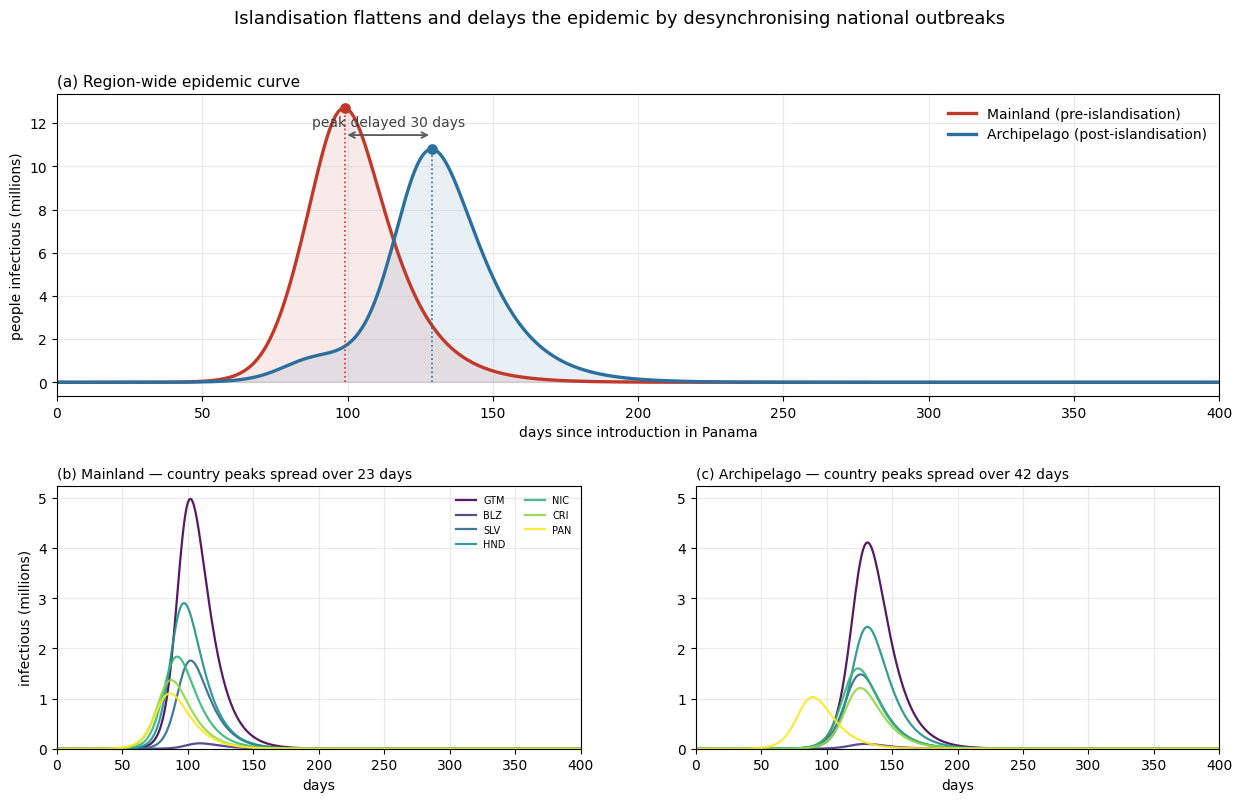

In [17]:
# --- C3. the figure ------------------------------------------------------
COL_PRE, COL_POST = "#c0392b", "#2a6f9e"
fig = plt.figure(figsize=(15, 8.5))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], hspace=0.32, wspace=0.22)

# (a) aggregate curves
ax = fig.add_subplot(gs[0, :])
ax.plot(t, tot_pre/1e6,  color=COL_PRE,  lw=2.4, label="Mainland (pre-islandisation)")
ax.plot(t, tot_post/1e6, color=COL_POST, lw=2.4, label="Archipelago (post-islandisation)")
ax.fill_between(t, tot_pre/1e6,  color=COL_PRE,  alpha=0.10)
ax.fill_between(t, tot_post/1e6, color=COL_POST, alpha=0.10)
for d, p, c in [(day_pre, peak_pre, COL_PRE), (day_post, peak_post, COL_POST)]:
    ax.plot([d, d], [0, p/1e6], color=c, ls=":", lw=1.2)
    ax.scatter([d], [p/1e6], color=c, zorder=5, s=45)
ax.annotate("", xy=(day_post, peak_post/1e6*1.06), xytext=(day_pre, peak_post/1e6*1.06),
            arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.3))
ax.text((day_pre+day_post)/2, peak_post/1e6*1.10,
        f"peak delayed {day_post-day_pre:.0f} days", ha="center", fontsize=10, color="0.25")
ax.set_xlim(0, 400); ax.set_ylabel("people infectious (millions)")
ax.set_xlabel("days since introduction in Panama")
ax.set_title("(a) Region-wide epidemic curve", fontsize=11, loc="left")
ax.legend(frameon=False); ax.grid(alpha=0.25)

# (b)+(c) per-country curves
for k, (I, lab, col) in enumerate([(I_pre,"Mainland",COL_PRE), (I_post,"Archipelago",COL_POST)]):
    ax = fig.add_subplot(gs[1, k])
    for i, c in enumerate(ISO):
        ax.plot(t, I[i]/1e6, lw=1.6, alpha=0.9,
                color=plt.cm.viridis(i/(nP-1)), label=c)
    ax.set_xlim(0, 400); ax.set_xlabel("days"); ax.grid(alpha=0.25)
    sp = (peak_days(I).max() - peak_days(I).min())
    ax.set_title(f"({'bc'[k]}) {lab} — country peaks spread over {sp:.0f} days",
                 fontsize=10, loc="left")
    if k == 0:
        ax.set_ylabel("infectious (millions)"); ax.legend(fontsize=7, ncol=2, frameon=False)
    ax.set_ylim(0, max(I_pre.max(), I_post.max())/1e6*1.05)

fig.suptitle("Islandisation flattens and delays the epidemic by desynchronising national outbreaks",
             fontsize=13, y=0.98)
fig.savefig("fig3_sir.png", dpi=300, bbox_inches="tight")
plt.show()


### Trials — sweep the mobility assumptions

The two uncertain parameters are `BORDER_BONUS` (how much everyday movement land borders carry)
and `KAPPA` (overall long-distance mobility). Sweeping both shows whether the qualitative
conclusion — delay and flattening, with attack rate unchanged — is robust, or an artefact
of one parameter choice. **Report this table: it is the honest robustness check.**

In [18]:
# --- C4. robustness sweep ------------------------------------------------
rows=[]
for bonus in [0.01, 0.02, 0.05, 0.10]:
    for kap in [0.005, 0.002, 0.0005]:
        KAPPA_, BONUS_ = kap, bonus
        def cpl(M, land):
            C=np.eye(nP)
            for i in range(nP):
                for j in range(nP):
                    if i==j: continue
                    v = KAPPA_*(REF/M[i,j])**THETA if np.isfinite(M[i,j]) and M[i,j]>0 else 0.0
                    if land and frozenset((ISO[i],ISO[j])) in BORDER: v += BONUS_
                    C[i,j]=v
            return C
        _,Ia,Ra = run_sir(cpl(COST_PRE,True))
        _,Ib,Rb = run_sir(cpl(COST_POST,False))
        ta,tb = Ia.sum(0), Ib.sum(0)
        rows.append(dict(border_bonus=bonus, kappa=kap,
                         delay_days = int(t[tb.argmax()]-t[ta.argmax()]),
                         peak_reduction_pct = round(100*(1-tb.max()/ta.max()),1),
                         attack_rate_change_pp = round(
                             100*(Rb[:,-1].sum()-Ra[:,-1].sum())/NPOP.sum(),2)))
sweep_sir = pd.DataFrame(rows)
print(sweep_sir.to_string(index=False))
print("\nIf delay stays positive and attack-rate change stays near zero across the grid,")
print("the qualitative conclusion is robust to the mobility assumptions.")


 border_bonus  kappa  delay_days  peak_reduction_pct  attack_rate_change_pp
         0.01 0.0050           8                 1.5                  -0.93
         0.01 0.0020           8                -3.5                  -0.83
         0.01 0.0005           9               -11.7                  -0.78
         0.02 0.0050          12                 4.1                  -1.62
         0.02 0.0020          14                -0.9                  -1.53
         0.02 0.0005          18                -7.1                  -1.48
         0.05 0.0050          26                16.5                  -3.34
         0.05 0.0020          30                15.0                  -3.28
         0.05 0.0005          38                14.1                  -3.25
         0.10 0.0050          40                30.3                  -5.43
         0.10 0.0020          46                30.3                  -5.40
         0.10 0.0005          54                30.5                  -5.38

If delay st

## Tying it together

The three components share one geometry (`ALPHA`) and one network, so the results are
directly comparable. Run this last for the numbers that go in your 2-pager.

In [19]:
# --- FINAL SUMMARY -------------------------------------------------------
print("="*68)
print(f"ISLANDISATION OF CENTRAL AMERICA — headline results (GAP = {GAP_KM} km)")
print("="*68)

print("\n[A] TRANSPORT / ROUTING  (Section A)")
print(cmp.groupby("tier")["cost_change_%"].mean().round(1).to_string())
print(f"  weighted mean cost change: {100*(w_post/w_pre-1):+.1f}%")
print("  -> long-haul transit is already maritime and barely moves;")
print("     the damage is concentrated in INTRA-REGIONAL trade.")

try:
    print("\n[B] BILATERAL TRADE  (Section B, gravity)")
    print(f"  estimated distance elasticity beta = {beta:.3f}")
    print(f"  mean predicted change in intra-CA bilateral trade: "
          f"{cf['trade_change_%'].mean():+.1f}%")
except NameError:
    print("\n[B] gravity section not run in this session")

print("\n[C] EPIDEMIC  (Section C, metapopulation SIR)")
print(f"  peak delayed  {day_post-day_pre:.0f} days")
print(f"  peak reduced  {100*(1-peak_post/peak_pre):.1f}%")
print(f"  final attack rate change {100*(R_post[:,-1].sum()-R_pre[:,-1].sum())/NPOP.sum():+.2f} pp")
print("  -> islandisation buys TIME, not immunity.")

print("\n" + "="*68)
print("THE TRADE-OFF:  the same fragmentation that raises intra-regional trade")
print("costs also desynchronises national outbreaks and flattens the regional")
print("epidemic curve. Connectivity is simultaneously an economic asset and an")
print("epidemiological liability.")
print("="*68)


ISLANDISATION OF CENTRAL AMERICA — headline results (GAP = 60 km)

[A] TRANSPORT / ROUTING  (Section A)
tier
CA export     11.1
intra-CA     143.1
long-haul     -0.2
  weighted mean cost change: +5.0%
  -> long-haul transit is already maritime and barely moves;
     the damage is concentrated in INTRA-REGIONAL trade.

[B] BILATERAL TRADE  (Section B, gravity)
  estimated distance elasticity beta = -1.233
  mean predicted change in intra-CA bilateral trade: -1.4%

[C] EPIDEMIC  (Section C, metapopulation SIR)
  peak delayed  30 days
  peak reduced  15.0%
  final attack rate change -3.28 pp
  -> islandisation buys TIME, not immunity.

THE TRADE-OFF:  the same fragmentation that raises intra-regional trade
costs also desynchronises national outbreaks and flattens the regional
epidemic curve. Connectivity is simultaneously an economic asset and an
epidemiological liability.
